# grades

This example joins two datasets into one table.

(Both datasets are fake. I made them up.)

Each row of `students` is a student in a class. Columns are:
- `name_family` would be called a "last name" in the USA and UK
- `name_given` contains "first" and "middle" names, if any
- `country_code` is the TLD for the student's nationality

Each row of `scores` is a student in the same class. Columns are:
- `attendance` [0, 100] score for showing up in class
- `homework` [0, 100] score for attempting the homework
- `project` [0, 100] score for doing a class project
- `exam` [0, 100] score on the final exam

I tried to reduce bias by _anonymizing_ the `scores` table. I assigned each student a random `id_student` number. The `scores` table includes `id_student`, but it does not show names or nationalities.

## project idea

Imagine you are 老师 for this class, and you must decide how to calculate grades. Create a `scores['total']` column which is a weighted average of other scores. Try a few different combinations of weights. How does this change the final scores? Which weights would you use? Explain your reasoning.


In [20]:
from pathlib import Path
import seaborn as sns
import pandas as pd

In [21]:
# Where are the datasets on your computer?
GRADES_DIR = Path.cwd().parent / "data" / "grades"

SCORES_PATH = GRADES_DIR / "scores.tsv"
STUDENTS_PATH = GRADES_DIR / "students.tsv"
print(f"Scores are here: {SCORES_PATH}")
print(f"Students are here: {STUDENTS_PATH}")

Scores are here: /Users/void/code/chengdu/science/data/grades/scores.tsv
Students are here: /Users/void/code/chengdu/science/data/grades/students.tsv


In [22]:
# Read the students table.
# This is a TSV (Tab-Separated Value) file,
# not CSV (Comma-Separated Value) file.
# The sep="\t" tells pandas to use the tab
# character (not a comma) as a separator.
students = (
    pd.read_csv(STUDENTS_PATH, sep="\t")
    .set_index('id_student')
    .sort_index()
)
students

,name_family,name_given,country_code
id_student,,,
104,Kennerly,Samuel,US
329,Torvalds,Linus Benedict,FI
466,Lovelace,Agusta Ada,UK
777,Sweigart,Al,CA
781,Hopper,Grace,US
926,van Rossum,Guido,NL
974,Babbage,Charles,UK


In [23]:
# Read the scores table. (This is also a TSV file.)
scores = (
    pd.read_csv(SCORES_PATH, sep="\t")
    .set_index('id_student')
    .sort_index()
)
scores

,attendance,homework,project,exam
id_student,,,,
104,80.0,40.0,20,10.0
329,NaN,NaN,91,NaN
466,100.0,100.0,100,100.0
777,42.0,42.0,42,42.0
781,90.0,86.0,90,85.0
926,50.0,60.0,78,0.0
974,60.0,70.0,80,90.0


In [24]:
# Fill missing scores with zeros
scores = scores.fillna(0)

# Convert scores to integers
scores = scores.astype(int)

scores

,attendance,homework,project,exam
id_student,,,,
104,80,40,20,10
329,0,0,91,0
466,100,100,100,100
777,42,42,42,42
781,90,86,90,85
926,50,60,78,0
974,60,70,80,90


In [25]:
# TODO: Replace this cell with your own choice of weights.
scores['total'] = (
    0.5 * scores['project'] +
    0.5 * scores['exam']
).astype(int)
scores

,attendance,homework,project,exam,total
id_student,,,,,
104,80,40,20,10,15
329,0,0,91,0,45
466,100,100,100,100,100
777,42,42,42,42,42
781,90,86,90,85,87
926,50,60,78,0,39
974,60,70,80,90,85


<Axes: ylabel='id_student'>

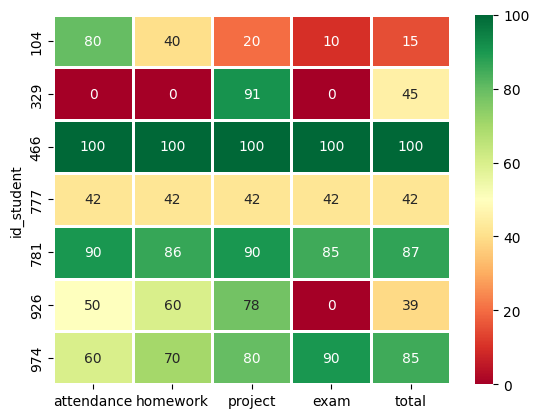

In [26]:
# We don't really need this. I just really like heatmaps.
# They're a good way to visualize a 2D numeric array.
sns.heatmap(
    scores,
    annot = True,
    fmt = ".0f",
    cmap = "RdYlGn",
    linewidths = 2,
)

In [27]:
# Join the tables and sort with the best score at the top.
# In SQL-style databases, we'd write something like this:
"""
SELECT *
FROM scores
JOIN students ON id_student
ORDER BY total DESC
"""

# In pandas, it looks like this:
scores.join(students).sort_values('total', ascending=False)

,attendance,homework,project,exam,total,name_family,name_given,country_code
id_student,,,,,,,,
466,100,100,100,100,100,Lovelace,Agusta Ada,UK
781,90,86,90,85,87,Hopper,Grace,US
974,60,70,80,90,85,Babbage,Charles,UK
329,0,0,91,0,45,Torvalds,Linus Benedict,FI
777,42,42,42,42,42,Sweigart,Al,CA
926,50,60,78,0,39,van Rossum,Guido,NL
104,80,40,20,10,15,Kennerly,Samuel,US
